In [1]:
!nvidia-smi
!pip install ultralytics

Sun Aug 30 09:29:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
import random

# A function to search for dataset path
def find_dataset_root():
    input_root = '/kaggle/input/'
    detected_path = None
    for root, dirs, files in os.walk(input_root):
        if 'train' in dirs and 'val' in dirs:
            detected_path = root
            break
    return detected_path

REAL_BASE_PATH = find_dataset_root()
print(f"Dataset Path: {REAL_BASE_PATH}")

Dataset Path: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data


In [3]:
import yaml

if REAL_BASE_PATH:
    data_config = {
        'path': REAL_BASE_PATH,
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images' if os.path.exists(os.path.join(REAL_BASE_PATH, 'test')) else 'val/images',
        'names': {0: 'Smoke', 1: 'Fire'} # Here a dictionary to avoid the old error by me
    }

    with open('/kaggle/working/data.yaml', 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)
    print("data.yaml has been created successfully, with the true classes names") 
    # The main error was in data card(from kaggle source)
    print(data_config['names'])   # To show real 'names' value
    print("0:smoke, 1:Fire")

data.yaml has been created successfully, with the true classes names
{0: 'Smoke', 1: 'Fire'}
0:smoke, 1:Fire


In [ ]:
def check_dataset_structure(base_path):
    base = Path(base_path)
    report = []

    
    splits = ['train', 'val', 'test']
    for split in splits:
        img_dir = base / split / 'images'
        lbl_dir = base / split / 'labels'
        
        if img_dir.exists() and lbl_dir.exists():
            images = sorted([f.stem for f in img_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
            labels = sorted([f.stem for f in lbl_dir.glob('*.txt')])
            
            
            mismatched_imgs = set(images) - set(labels)
            mismatched_lbls = set(labels) - set(images)
            
            report.append({
                'Split': split,
                'Total Images': len(images),
                'Total Labels': len(labels),
                'Mismatched Images': len(mismatched_imgs),
                'Mismatched Labels': len(mismatched_lbls)
            })
        else:
            print(f"File does not exist or not valid  {split}")
            
    df_report = pd.DataFrame(report)
    print("\n--- dataset structure report---")
    print(df_report.to_string(index=False))
    return df_report
    
check_dataset_structure(REAL_BASE_PATH)


--- dataset structure report---
Split  Total Images  Total Labels  Mismatched Images  Mismatched Labels
train         14122         14122                  0                  0
  val          3099          3099                  0                  0
 test          4306          4306                  0                  0


,Split,Total Images,Total Labels,Mismatched Images,Mismatched Labels
0,train,14122,14122,0,0
1,val,3099,3099,0,0
2,test,4306,4306,0,0


/tmp/ipykernel_22/3077681096.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Class', y='Count', data=df_class, palette='Oranges_r')


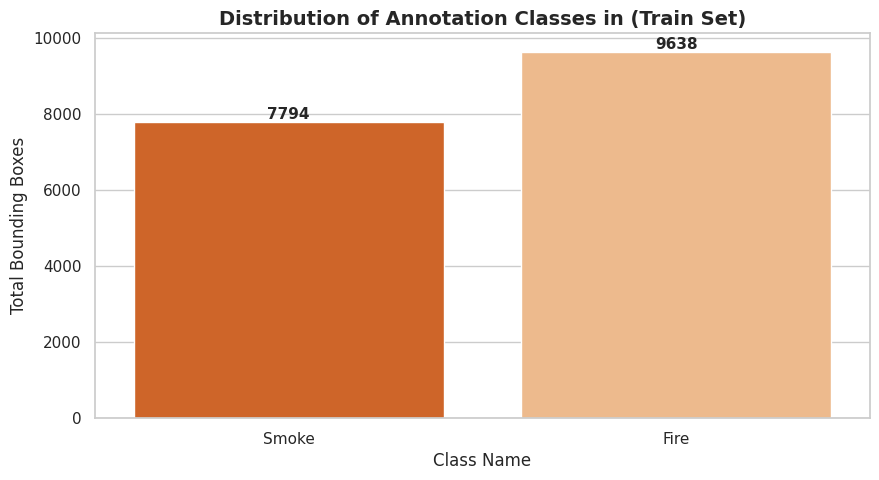


--_Classes distribution report ---
Class  Count  Percentage
Smoke   7794   44.710877
 Fire   9638   55.289123


,Class,Count,Percentage
0,Smoke,7794,44.710877
1,Fire,9638,55.289123


In [5]:
def analyze_class_distribution(base_path, class_names, split='train'):
    label_dir = Path(base_path) / split / 'labels'
    class_counts = Counter()
    total_boxes = 0
    
    for label_file in label_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    total_boxes += 1
                    
    
    data = []
    for cid, count in class_counts.items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown ({cid})"
        data.append({'Class': name, 'Count': count, 'Percentage': (count / total_boxes) * 100})
        
    df_class = pd.DataFrame(data)
    
    
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(x='Class', y='Count', data=df_class, palette='Oranges_r')
    
    
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')
        
    plt.title(f'Distribution of Annotation Classes in ({split.capitalize()} Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Class Name', fontsize=12)
    plt.ylabel('Total Bounding Boxes', fontsize=12)
    plt.show()
    
    print("\n--_Classes distribution report ---")
    print(df_class.to_string(index=False))
    return df_class


class_names = {0: 'Smoke', 1: 'Fire'} 
analyze_class_distribution('/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data', class_names, split='train')

Found from all 


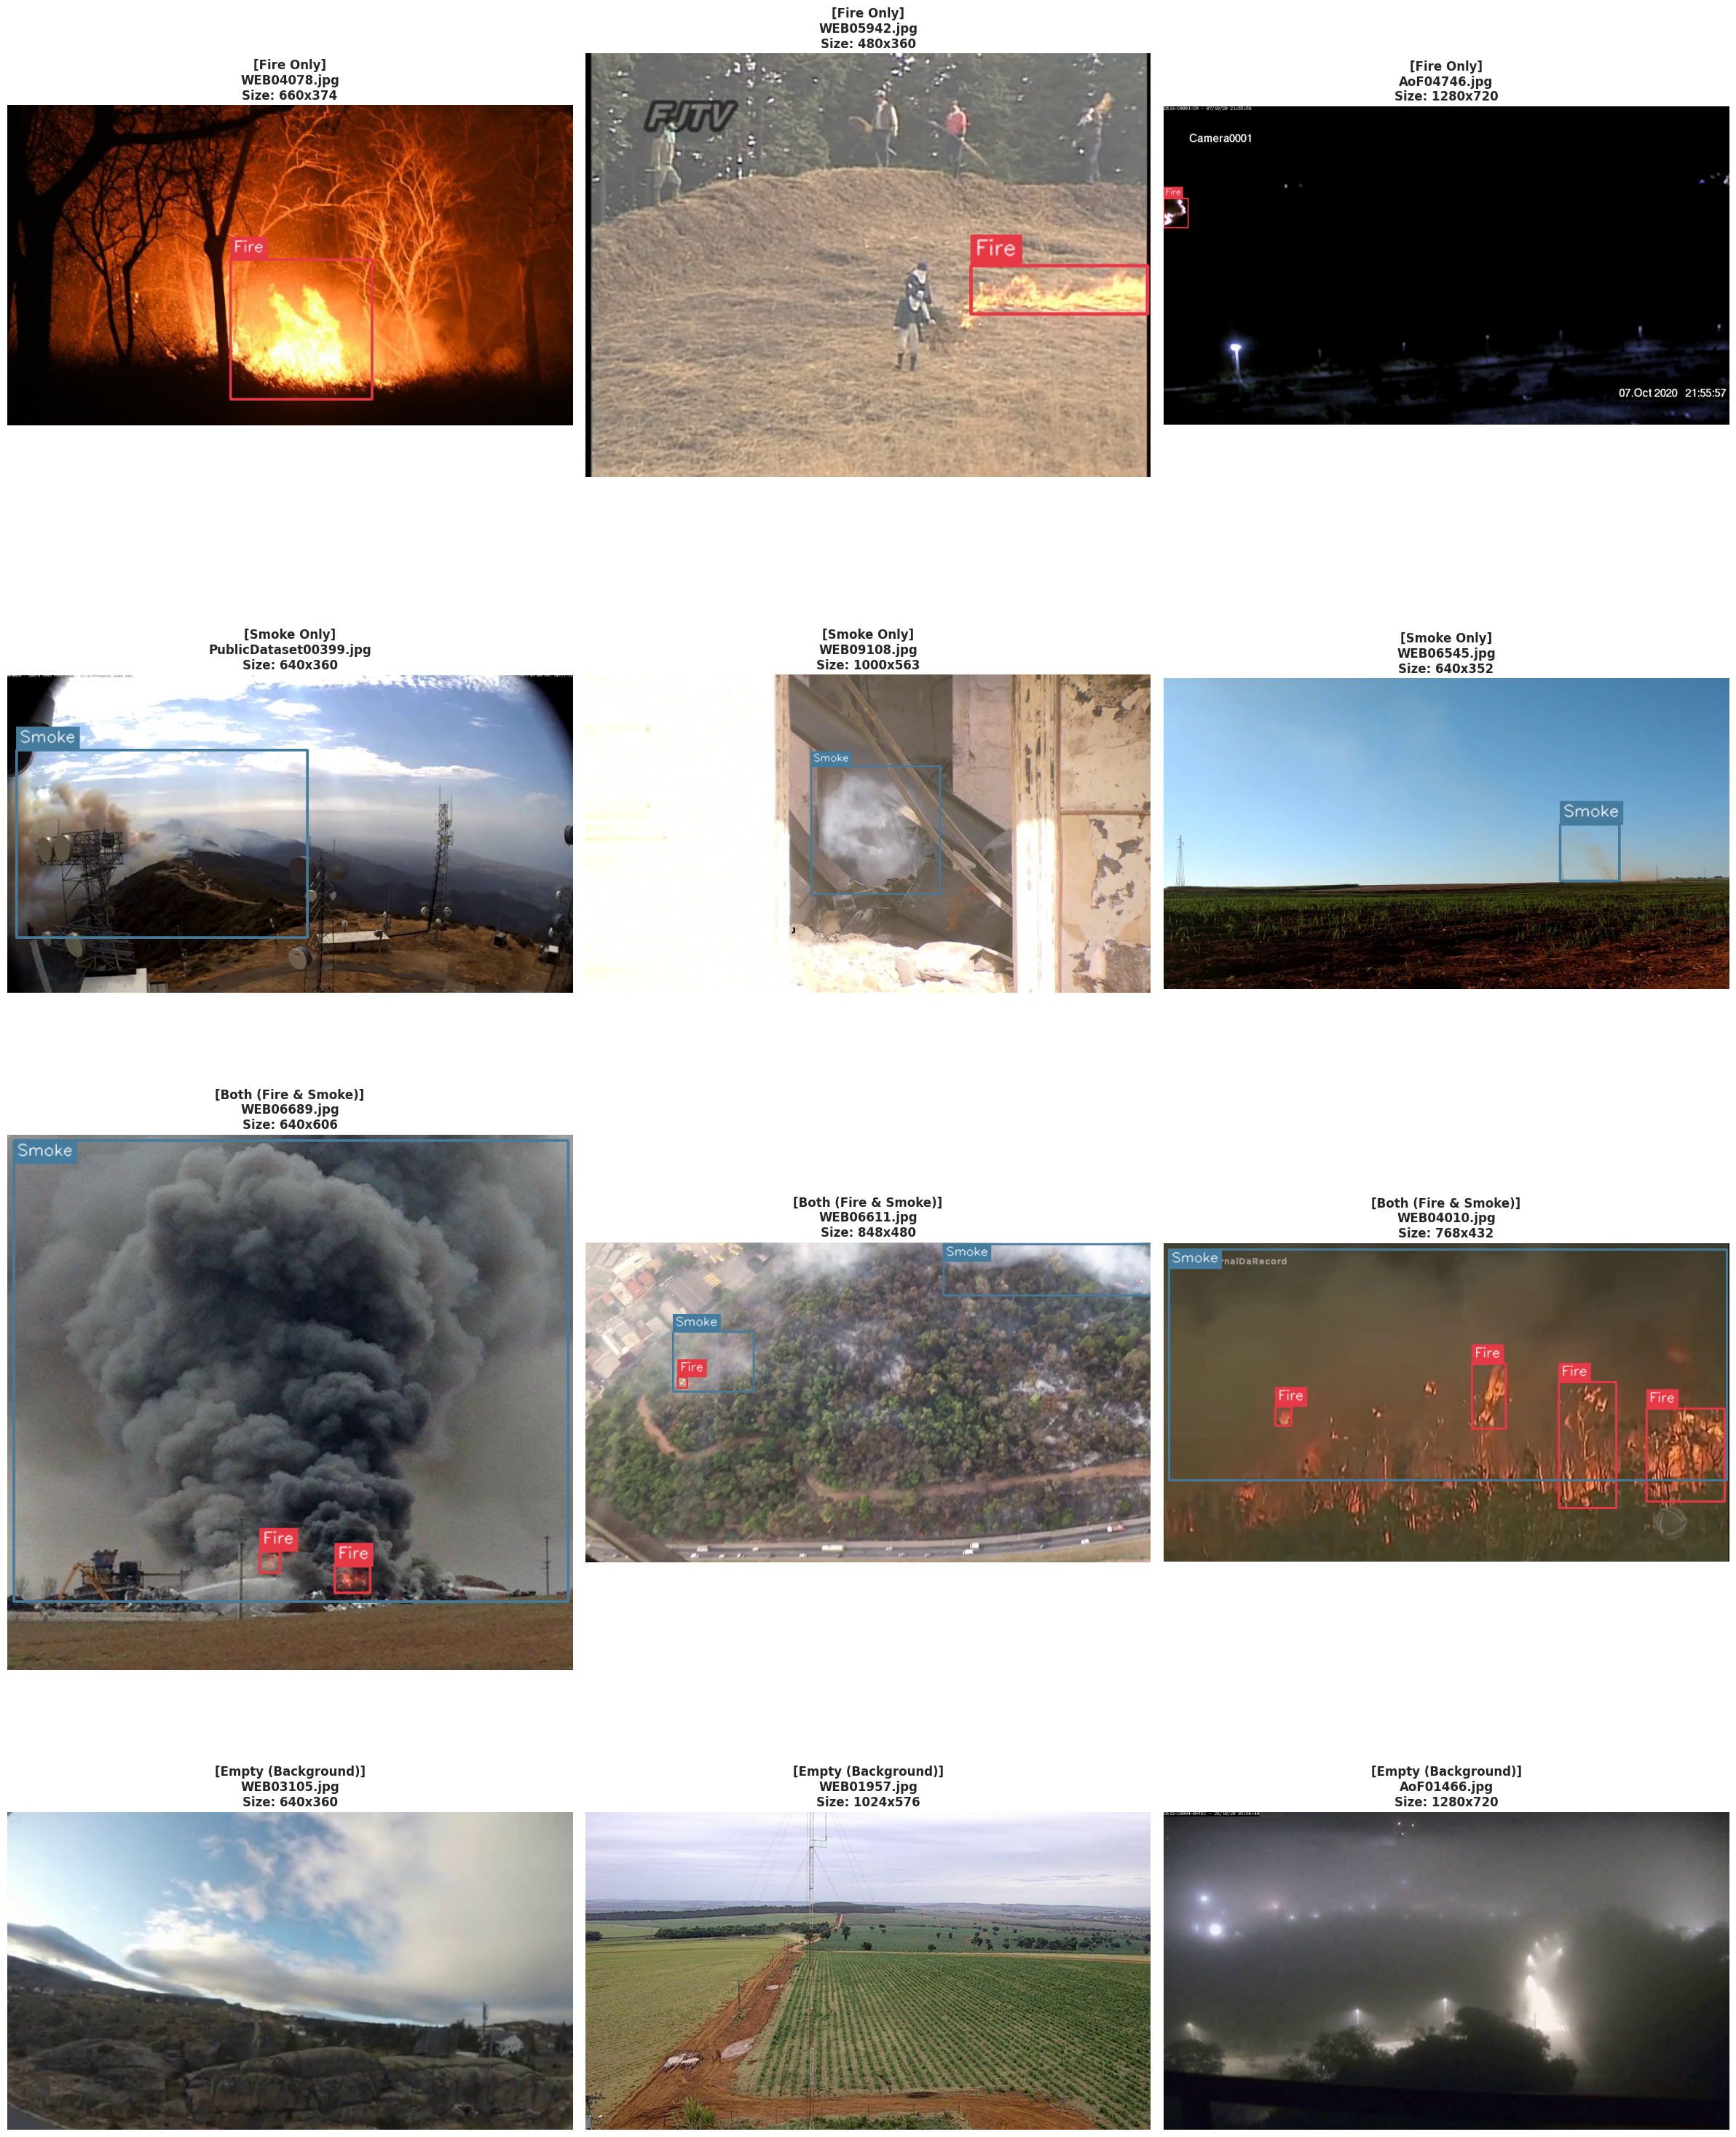

In [6]:
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_stratified_samples_fast(base_path, class_names, split='train', samples_per_cat=3, cols=3):
    base = Path(base_path)
    img_dir = base / split / 'images'
    lbl_dir = base / split / 'labels'
    
    
    categories = {
        'Fire Only': [],
        'Smoke Only': [],
        'Both (Fire & Smoke)': [],
        'Empty (Background)': []
    }
    
    
    all_images = list(img_dir.glob('*'))
    random.shuffle(all_images)
    
    for img_path in all_images:
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
            
        all_full = all(len(lst) >= samples_per_cat for lst in categories.values())
        if all_full:
            print("Found from all ")
            break
            
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        present_classes = set()
        
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if parts:
                        present_classes.add(int(parts[0]))
        
        if 0 in present_classes and 1 in present_classes:
            if len(categories['Both (Fire & Smoke)']) < samples_per_cat:
                categories['Both (Fire & Smoke)'].append(img_path)
                
        elif 0 in present_classes:
            if len(categories['Smoke Only']) < samples_per_cat:
                categories['Smoke Only'].append(img_path)
                
        elif 1 in present_classes:
            if len(categories['Fire Only']) < samples_per_cat:
                categories['Fire Only'].append(img_path)
                
        else:
            if len(categories['Empty (Background)']) < samples_per_cat:
                categories['Empty (Background)'].append(img_path)
    
    selected_samples = []
    for cat_name, paths in categories.items():
        for p in paths:
            selected_samples.append((p, cat_name))
            
    total_samples = len(selected_samples)
    if total_samples == 0:
        print("Didn't find any photo !")
        return
        

    rows = (total_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(24, 8 * rows))
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    colors = {0:  (69, 123, 157), 1: (230, 57, 70)}  # here 0 smoke (Blue), 1 Fire (Red)
    
    for idx, (img_path, cat_name) in enumerate(selected_samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img, _ = img.shape
        
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if not parts: continue
                    
                    cid, x_c, y_c, w, h = map(float, parts)
                    
                    x1 = int((x_c - w / 2) * w_img)
                    y1 = int((y_c - h / 2) * h_img)
                    x2 = int((x_c + w / 2) * w_img)
                    y2 = int((y_c + h / 2) * h_img)
                    
                    color = colors.get(int(cid), (40, 167, 69))
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    
                    label_text = class_names.get(int(cid), str(int(cid)))
                    font_scale = 0.6
                    font_thick = 1
                    (text_w, text_h), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thick)
                    
                    if y1 - text_h - baseline - 6 > 0:
                        bg_y1, bg_y2, text_y = y1 - text_h - baseline - 6, y1, y1 - baseline - 3
                    else:
                        bg_y1, bg_y2, text_y = y1, y1 + text_h + baseline + 6, y1 + text_h + 3
                        
                    bg_x2 = min(x1 + text_w + 8, w_img)
                    cv2.rectangle(img, (x1, bg_y1), (bg_x2, bg_y2), color, -1)
                    cv2.putText(img, label_text, (x1 + 4, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thick, cv2.LINE_AA)
                    
        axes_flat[idx].imshow(img)
        axes_flat[idx].set_title(f"[{cat_name}]\n{img_path.name}\nSize: {w_img}x{h_img}", fontsize=12, fontweight='bold')
        axes_flat[idx].axis('off')
        
    for i in range(total_samples, len(axes_flat)):
        axes_flat[i].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_stratified_samples_fast(
    '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data', 
    class_names, 
    split='train', 
    samples_per_cat=3, 
    cols=3             
)

<Figure size 800x700 with 0 Axes>

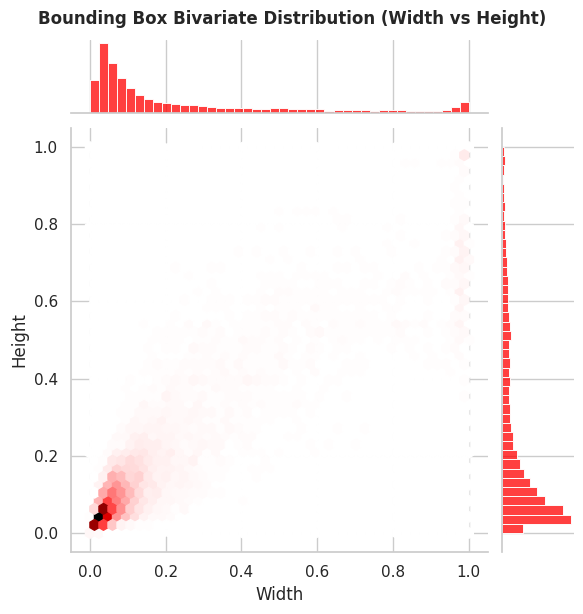


--- Descriptive accuracy of object dimensions ---
              Width        Height  Aspect_Ratio
count  17432.000000  17432.000000  17432.000000
mean       0.247850      0.239862      1.076841
std        0.278649      0.237361      0.834620
min        0.000000      0.000000      0.000000
25%        0.048069      0.059722      0.602034
50%        0.113281      0.133333      0.874308
75%        0.361111      0.375000      1.303697
max        1.000000      1.000000     22.248576

 Percentage of very small objects (less than 10% of image size): 35.25%


,Width,Height,Aspect_Ratio
0,0.867188,0.605556,1.432050
1,0.217188,0.358333,0.606103
2,0.290000,0.906300,0.319982
3,0.156863,0.044444,3.529332
4,0.250000,0.050000,4.999900
...,...,...,...
17427,0.028465,0.044444,0.640456
17428,0.962871,0.542593,1.774572
17429,0.123536,0.246725,0.500700
17430,0.093750,0.152778,0.613632


In [7]:
def analyze_box_dimensions(base_path, split='train'):
    label_dir = Path(base_path) / split / 'labels'
    widths = []
    heights = []
    
    for label_file in label_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                
                    widths.append(float(parts[3]))
                    heights.append(float(parts[4]))
                    
    df_boxes = pd.DataFrame({'Width': widths, 'Height': heights})
    df_boxes['Aspect_Ratio'] = df_boxes['Width'] / (df_boxes['Height'] + 1e-6)
    
    
    plt.figure(figsize=(8, 7))
    sns.jointplot(x='Width', y='Height', data=df_boxes, kind='hex', color='red')
    plt.suptitle('Bounding Box Bivariate Distribution (Width vs Height)', y=1.02, fontsize=12, fontweight='bold')
    plt.show()
    
    
    print("\n--- Descriptive accuracy of object dimensions ---")
    print(df_boxes.describe())
    
    small_objects = df_boxes[(df_boxes['Width'] < 0.1) & (df_boxes['Height'] < 0.1)]
    print(f"\n Percentage of very small objects (less than 10% of image size): {len(small_objects)/len(df_boxes)*100:.2f}%")
    
    return df_boxes


analyze_box_dimensions('/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data', split='train')

In [8]:
from ultralytics import YOLO


model = YOLO('yolo26m.pt') 

metrics = model.train(
    data='/kaggle/working/data.yaml',
    epochs=85,
    imgsz=640,
    batch=32,
    device=[-1,-1],
    mosaic=1.0,             # موجود شرحها على موقع التراليتيكس
    close_mosaic=20,
    degrees=10.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mixup=0.1, 
    workers=4,
    save=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0, 1]
Ultralytics 8.4.135 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10.0, deterministic=True, device=0,1,

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/85      8.94G      1.756      1.924    0.01642         29        640: 100% ━━━━━━━━━━━━ 441/441 1.2it/s 6:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.3it/s 14.8s
                   all       3094       3917      0.567      0.473       0.49      0.222

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/85      8.94G      1.837      2.106    0.01766         19        640: 100% ━━━━━━━━━━━━ 441/441 1.3it/s 5:47
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.3it/s 14.8s
                   all       3094       3917      0.442       0.37      0.346      0.135

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       4/85      9.03G       1.91      2.199    0.01866         33        640: 100% ━━━━━━━━━